## Global Disaster Patterns and Humanitarian Response Needs: A Spatiotemporal Analysis of Disaster Events, 2000–2025.
General objective

1. To examine the spatial and temporal patterns of global disaster events between 2000 and 2025 and identify geographic and disaster-type patterns associated with heightened humanitarian response needs.

Specific Objectives
1. To characterize the temporal distribution of disaster events globally from 2000 to 2025.
2. To examine the geographic distribution and concentration of disaster events across countries and regions.
3. To compare the temporal and geographic patterns of major disaster types.
4. To identify recurrent disaster hotspots and characterize their humanitarian response profiles.

Research Questions
1. How have the frequency and composition of global disaster events changed between 2000 and 2025?
2. Which countries and regions experienced the greatest concentration of disaster events during 2000–2025?
3. Which countries experienced recurrent exposure to multiple disaster types during the study period?


In [2]:
# importing relevant libraries and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# File paths 
drought_path = r"C:\Users\user\Desktop\DoC\Drought_clean.csv"
eq_path      = r"C:\Users\user\Desktop\DoC\Earthquake_clean.csv"
eruption_path = r"C:\Users\user\Desktop\DoC\Eruption_clean.csv"
flood_path   = r"C:\Users\user\Desktop\DoC\Flood_clean.csv"
fire_path    = r"C:\Users\user\Desktop\DoC\Forest_Fires_clean.csv"
tc_path      = r"C:\Users\user\Desktop\DoC\Tropical_Cyclone_clean.csv"

# Loading datasets
drought  = pd.read_csv(drought_path)
eq       = pd.read_csv(eq_path)
eruption = pd.read_csv(eruption_path)
flood    = pd.read_csv(flood_path)
fire     = pd.read_csv(fire_path)
tc       = pd.read_csv(tc_path)

print("Shapes:")
print("Drought          :", drought.shape)
print("Earthquake       :", eq.shape)
print("Eruption         :", eruption.shape)
print("Flood            :", flood.shape)
print("Forest Fires     :", fire.shape)
print("Tropical Cyclone :", tc.shape)

Shapes:
Drought          : (240, 14)
Earthquake       : (20290, 16)
Eruption         : (61, 18)
Flood            : (2126, 17)
Forest Fires     : (3051, 14)
Tropical Cyclone : (405, 20)


In [3]:
# Inspecting columns of each dataset
print("DROUGHT columns")
print(drought.columns.tolist())
print("\nTROPICAL CYCLONE columns")
print(tc.columns.tolist())
print("\nERUPTION columns")
print(eruption.columns.tolist())
print("\nFOREST FIRES columns")
print(fire.columns.tolist())
print("\nFLOOD columns")
print(flood.columns.tolist())
print("\nEARTHQUAKE columns")
print(eq.columns.tolist())

DROUGHT columns
['Description', 'Alertlevel', 'Alertscore', 'Episodealertscore', 'Country', 'Fromdate', 'Todate', 'Severity (km2)', 'Iso3', 'Gdacs id', 'Duration (days)', 'Impact', 'Longitude', 'Latitude']

TROPICAL CYCLONE columns
['description', 'alertlevel', 'alertscore', 'episodealertlevel', 'episodealertscore', 'fromdate', 'todate', 'severity', 'severitytext', 'source', 'iso3', 'GDACS ID', 'Exposed countries', 'Exposed population', 'Maximum wind speed (km/h)', 'Maximum storm surge (m)', 'Vulnerability', 'longitude', 'latitude', 'Category']

ERUPTION columns
['description', 'alertlevel', 'alertscore', 'episodealertlevel', 'episodealertscore', 'country', 'fromdate', 'todate', 'severity', 'source', 'iso3', 'GDACS ID', 'Exposed Population 30km', 'Exposed Population 100km', 'Max Volc. Explosivity Index VEI', 'Population Exposure Index PEI', 'longitude', 'latitude']

FOREST FIRES columns
['description', 'alertlevel', 'alertscore', 'episodealertscore', 'country', 'fromdate', 'todate', 's

In [4]:
# Standardise column names across all datasets
# creating a consistent set of core columns for the master table:
# disaster_type, country, iso3, fromdate, todate, alertlevel, alertscore,
# longitude, latitude, severity_proxy, exposed_pop, deaths, displaced, gdacs_id

# --- Drought ---
drought = drought.rename(columns={
    'Description': 'description',
    'Alertlevel': 'alertlevel',
    'Alertscore': 'alertscore',
    'Episodealertscore': 'episodealertscore',
    'Country': 'country',
    'Fromdate': 'fromdate',
    'Todate': 'todate',
    'Severity (km2)': 'severity_km2',
    'Iso3': 'iso3',
    'Gdacs id': 'gdacs_id',
    'Duration (days)': 'duration_days',
    'Impact': 'impact',
    'Longitude': 'longitude',
    'Latitude': 'latitude'
})
drought['disaster_type'] = 'Drought'

# --- Tropical Cyclone ---
tc = tc.rename(columns={
    'GDACS ID': 'gdacs_id',
    'Exposed population': 'exposed_pop',
    'Maximum wind speed (km/h)': 'max_wind_kmh',
    'Maximum storm surge (m)': 'max_surge_m',
    'Category': 'category'
})
tc['disaster_type'] = 'Tropical Cyclone'
# keep original 'Exposed countries' as country for now
tc['country'] = tc['Exposed countries']

# --- Eruption ---
eruption = eruption.rename(columns={
    'GDACS ID': 'gdacs_id',
    'Exposed Population 30km': 'exposed_pop_30km',
    'Exposed Population 100km': 'exposed_pop_100km',
    'Max Volc. Explosivity Index VEI': 'vei',
    'Population Exposure Index PEI': 'pei'
})
eruption['disaster_type'] = 'Volcanic Eruption'

# --- Forest Fires ---
fire = fire.rename(columns={
    'severity (ha)': 'severity_ha',
    'GDACS ID': 'gdacs_id',
    'People affected': 'people_affected',
    'Duration (days)': 'duration_days'
})
fire['disaster_type'] = 'Forest Fire'

# --- Flood ---
# Flood has an unnamed index column
if flood.columns[0].startswith('Unnamed') or flood.columns[0] == '':
    flood = flood.drop(columns=flood.columns[0])
flood = flood.rename(columns={
    'severity (magnitude)': 'severity_mag',
    'Death': 'deaths',
    'Displaced': 'displaced',
    'GDACS_ID': 'gdacs_id'
})
flood['disaster_type'] = 'Flood'

# --- Earthquake ---
eq = eq.rename(columns={
    'Earthquake Magnitude (M)': 'magnitude',
    'Depth (km)': 'depth_km',
    'Exposed Population (within 100 km)': 'exposed_pop'
})
eq['disaster_type'] = 'Earthquake'

print("Standardisation completed.")

Standardisation completed.


In [5]:
# Parse dates and create year columns
def parse_dates(df, from_col='fromdate', to_col='todate'):
    df[from_col] = pd.to_datetime(df[from_col], errors='coerce')
    if to_col in df.columns:
        df[to_col] = pd.to_datetime(df[to_col], errors='coerce')
    df['year'] = df[from_col].dt.year
    df['month'] = df[from_col].dt.month
    return df

drought   = parse_dates(drought)
tc        = parse_dates(tc)
eruption  = parse_dates(eruption)
fire      = parse_dates(fire)
flood     = parse_dates(flood)
eq        = parse_dates(eq)

print("Date parsing done. Year ranges:")
for name, df in [('Drought', drought), ('TC', tc), ('Eruption', eruption),
                 ('Fire', fire), ('Flood', flood), ('EQ', eq)]:
    print(f"{name:12s}: {df['year'].min()} – {df['year'].max()}  (n={len(df)})")

Date parsing done. Year ranges:
Drought     : 2017 – 2025  (n=240)
TC          : 2008 – 2025  (n=405)
Eruption    : 2011 – 2025  (n=61)
Fire        : 2021 – 2025  (n=3051)
Flood       : 2000 – 2025  (n=2126)
EQ          : 2000 – 2025  (n=20290)


In [6]:
# Create a unified master dataframe with core columns
core_cols = ['disaster_type', 'country', 'iso3', 'fromdate', 'todate', 'year',
             'alertlevel', 'alertscore', 'longitude', 'latitude', 'gdacs_id']

# Prepare each dataset with the core columns (fill missing ones)
def prepare(df, extra_map=None):
    d = df.copy()
    for c in core_cols:
        if c not in d.columns:
            d[c] = np.nan
    # keep some useful extras
    if extra_map:
        for src, dst in extra_map.items():
            if src in d.columns:
                d[dst] = d[src]
    return d[core_cols + list(extra_map.values()) if extra_map else core_cols]

drought_m = prepare(drought, {'severity_km2': 'severity', 'duration_days': 'duration_days'})
tc_m      = prepare(tc, {'exposed_pop': 'exposed_pop', 'max_wind_kmh': 'severity'})
eruption_m= prepare(eruption, {'exposed_pop_100km': 'exposed_pop', 'vei': 'severity'})
fire_m    = prepare(fire, {'severity_ha': 'severity', 'people_affected': 'exposed_pop', 'duration_days': 'duration_days'})
flood_m   = prepare(flood, {'severity_mag': 'severity', 'deaths': 'deaths', 'displaced': 'displaced'})
eq_m      = prepare(eq, {'magnitude': 'severity', 'exposed_pop': 'exposed_pop', 'depth_km': 'depth_km'})

master = pd.concat([drought_m, tc_m, eruption_m, fire_m, flood_m, eq_m],
                   ignore_index=True, sort=False)

# Clean alertlevel to Title case
master['alertlevel'] = master['alertlevel'].astype(str).str.strip().str.title()
master.loc[master['alertlevel'].isin(['Nan', 'None', '']), 'alertlevel'] = np.nan

# Basic filters: keep 2000–2025
master = master[(master['year'] >= 2000) & (master['year'] <= 2025)].copy()

print("Master shape:", master.shape)
print(master['disaster_type'].value_counts())
print("\nYear range:", master['year'].min(), "–", master['year'].max())
master.head(3)

Master shape: (26173, 17)
disaster_type
Earthquake           20290
Forest Fire           3051
Flood                 2126
Tropical Cyclone       405
Drought                240
Volcanic Eruption       61
Name: count, dtype: int64

Year range: 2000 – 2025


,disaster_type,country,iso3,fromdate,todate,year,alertlevel,alertscore,longitude,latitude,gdacs_id,severity,duration_days,exposed_pop,deaths,displaced,depth_km
0,Drought,"Germany, Denmark, France, Latvia, Poland, Sweden",DEU,2017-07-21,2019-02-09 15:07:00,2017,Green,1.0,11.087,53.882,DR 1012168,80936.0,569.0,NaN,NaN,NaN,NaN
1,Drought,Uzbekistan,UZB,2017-11-21,2018-09-06 09:57:00,2017,Green,1.0,65.500,40.996,DR 1012172,18686.0,289.0,NaN,NaN,NaN,NaN
2,Drought,Brazil,BRA,2017-12-21,2018-09-06 09:57:00,2017,Green,1.0,-50.105,-21.917,DR 1012174,87604.0,259.0,NaN,NaN,NaN,NaN


In [7]:
# Data quality overview
print("Missing values (%):")
print((master.isna().mean() * 100).round(1).sort_values(ascending=False))

print("\nAlert level distribution:")
print(master['alertlevel'].value_counts(dropna=False))

print("\nEvents per disaster type:")
print(master['disaster_type'].value_counts())

print("\nUnique countries (approx):", master['country'].nunique())
print("Unique ISO3:", master['iso3'].nunique())

Missing values (%):
deaths           91.9
displaced        91.9
duration_days    87.4
gdacs_id         77.5
depth_km         22.5
exposed_pop       9.0
country           6.9
iso3              4.1
disaster_type     0.0
longitude         0.0
alertscore        0.0
alertlevel        0.0
year              0.0
todate            0.0
fromdate          0.0
severity          0.0
latitude          0.0
dtype: float64

Alert level distribution:
alertlevel
Green     25488
Orange      548
Red         137
Name: count, dtype: int64

Events per disaster type:
disaster_type
Earthquake           20290
Forest Fire           3051
Flood                 2126
Tropical Cyclone       405
Drought                240
Volcanic Eruption       61
Name: count, dtype: int64

Unique countries (approx): 818
Unique ISO3: 241


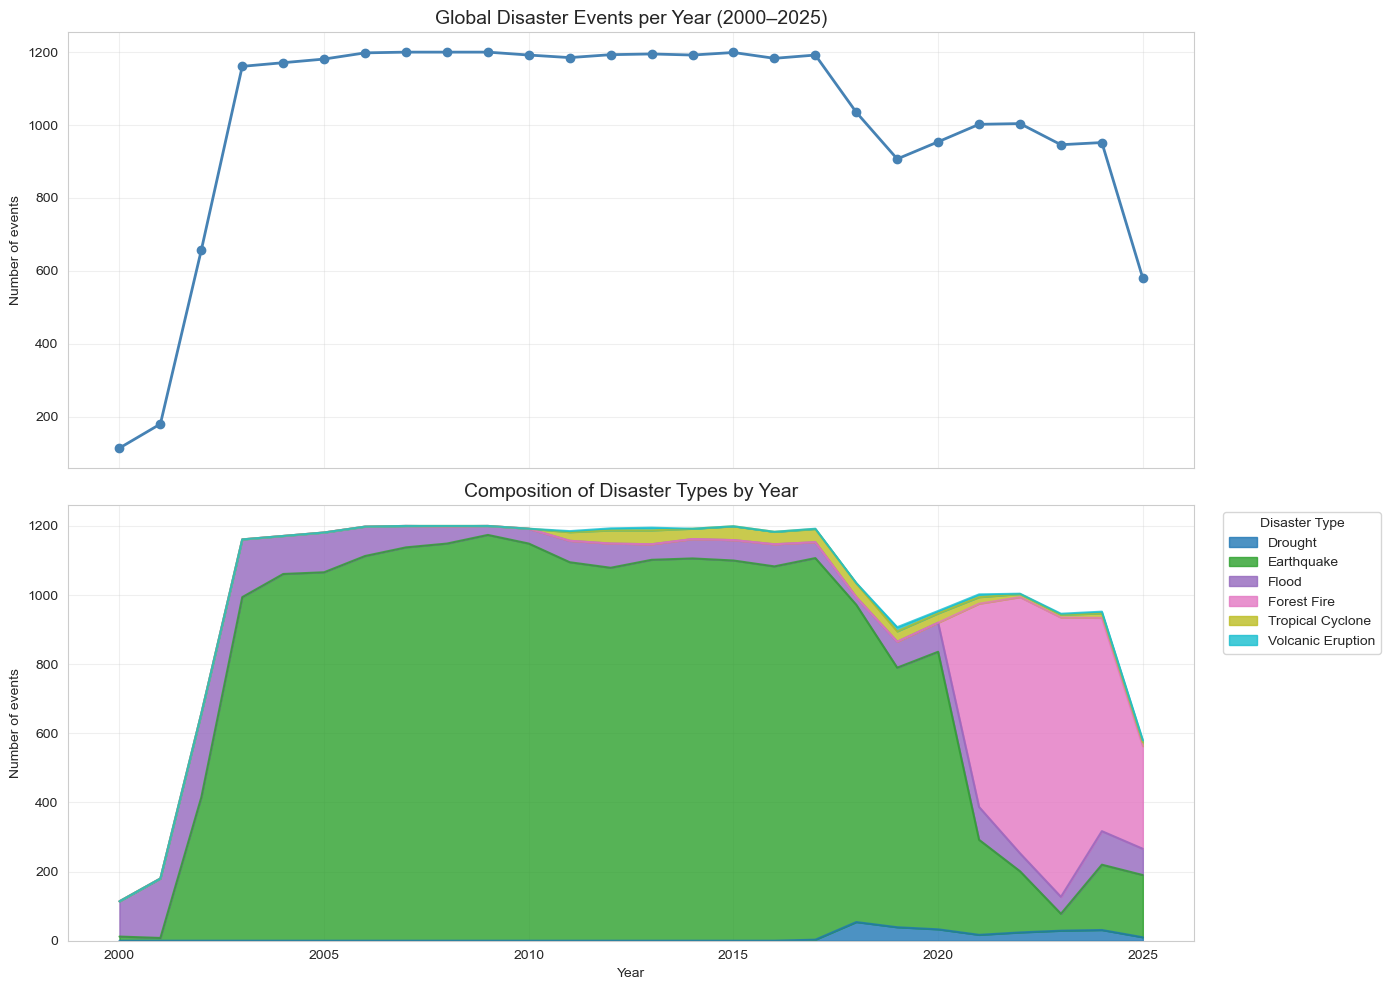

Yearly totals (first & last 5 years):
year
2000     114
2001     180
2002     657
2003    1161
2004    1171
Name: n_events, dtype: int64
...
year
2021    1002
2022    1004
2023     946
2024     952
2025     580
Name: n_events, dtype: int64


In [8]:
# Temporal trends – total events per year and by type
yearly = master.groupby('year').size().rename('n_events')
yearly_type = master.groupby(['year', 'disaster_type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Total events
axes[0].plot(yearly.index, yearly.values, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Global Disaster Events per Year (2000–2025)', fontsize=14)
axes[0].set_ylabel('Number of events')
axes[0].grid(True, alpha=0.3)

# Stacked by type
yearly_type.plot(kind='area', stacked=True, ax=axes[1], alpha=0.8, colormap='tab10')
axes[1].set_title('Composition of Disaster Types by Year', fontsize=14)
axes[1].set_ylabel('Number of events')
axes[1].set_xlabel('Year')
axes[1].legend(title='Disaster Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Yearly totals (first & last 5 years):")
print(yearly.head())
print("...")
print(yearly.tail())

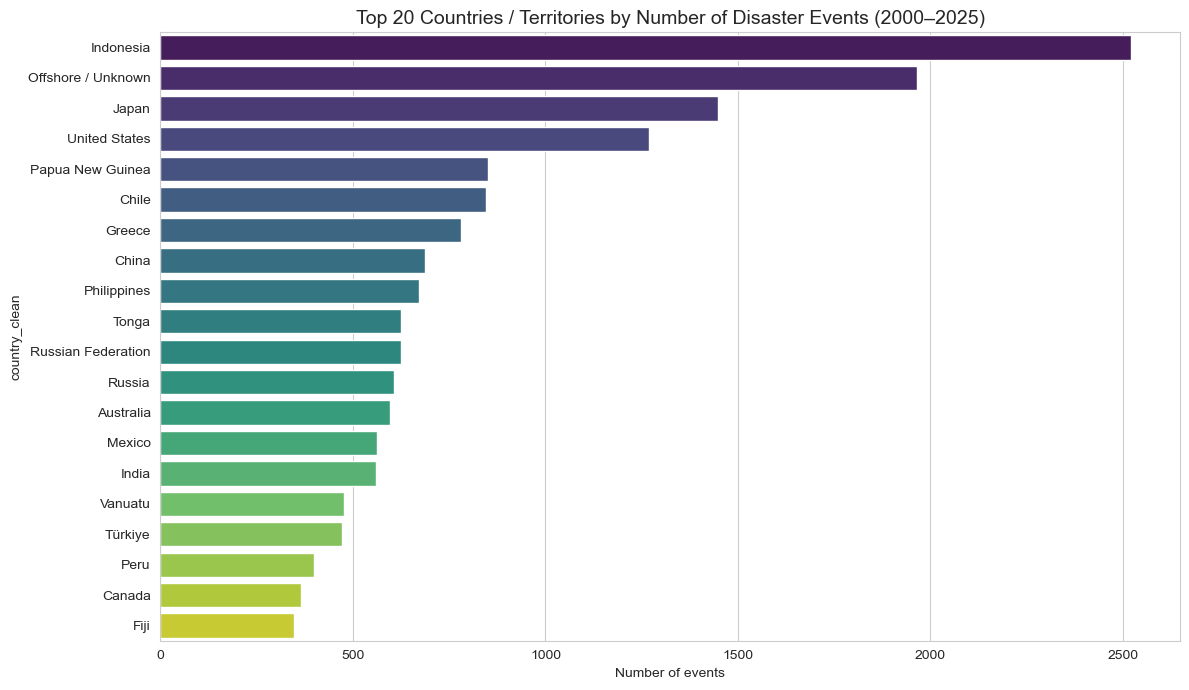

Top 15 countries:
country_clean
Indonesia             2522
Offshore / Unknown    1965
Japan                 1447
United States         1270
Papua New Guinea       851
Chile                  846
Greece                 780
China                  688
Philippines            672
Tonga                  624
Russian Federation     624
Russia                 607
Australia              595
Mexico                 563
India                  559
Name: count, dtype: int64


In [9]:
# Top countries by total events and by disaster type
# Clean country names a bit (many multi-country entries exist)
master['country_clean'] = master['country'].astype(str).str.split(',').str[0].str.strip()
# replace empty / nan
master.loc[master['country_clean'].isin(['', 'nan', 'None', 'Off-shore']), 'country_clean'] = 'Offshore / Unknown'

top_countries = master['country_clean'].value_counts().head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 20 Countries / Territories by Number of Disaster Events (2000–2025)', fontsize=14)
plt.xlabel('Number of events')
plt.tight_layout()
plt.show()

print("Top 15 countries:")
print(top_countries.head(15))

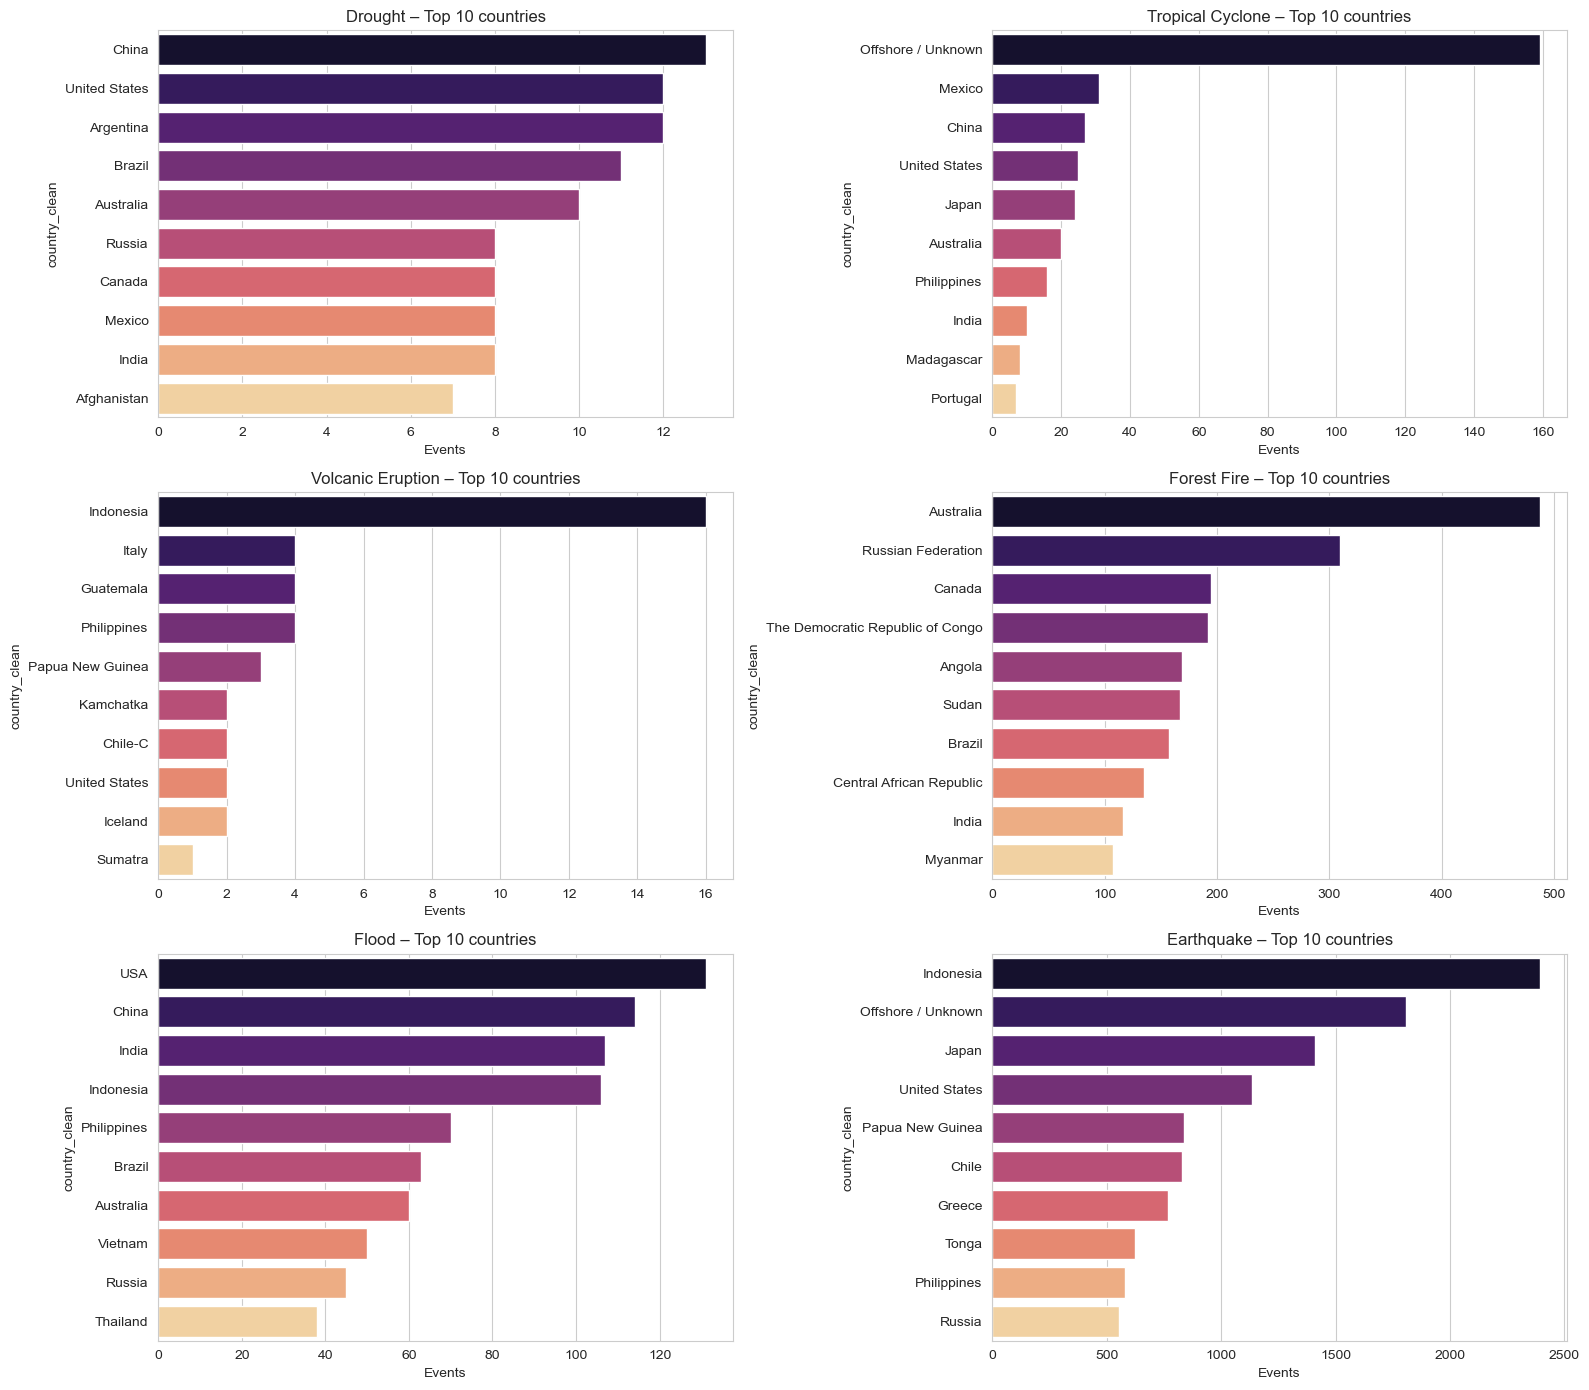

In [10]:
# Top countries for each disaster type
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, dtype in enumerate(master['disaster_type'].unique()):
    sub = master[master['disaster_type'] == dtype]
    top = sub['country_clean'].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, ax=axes[i], palette='magma')
    axes[i].set_title(f'{dtype} – Top 10 countries')
    axes[i].set_xlabel('Events')

plt.tight_layout()
plt.show()

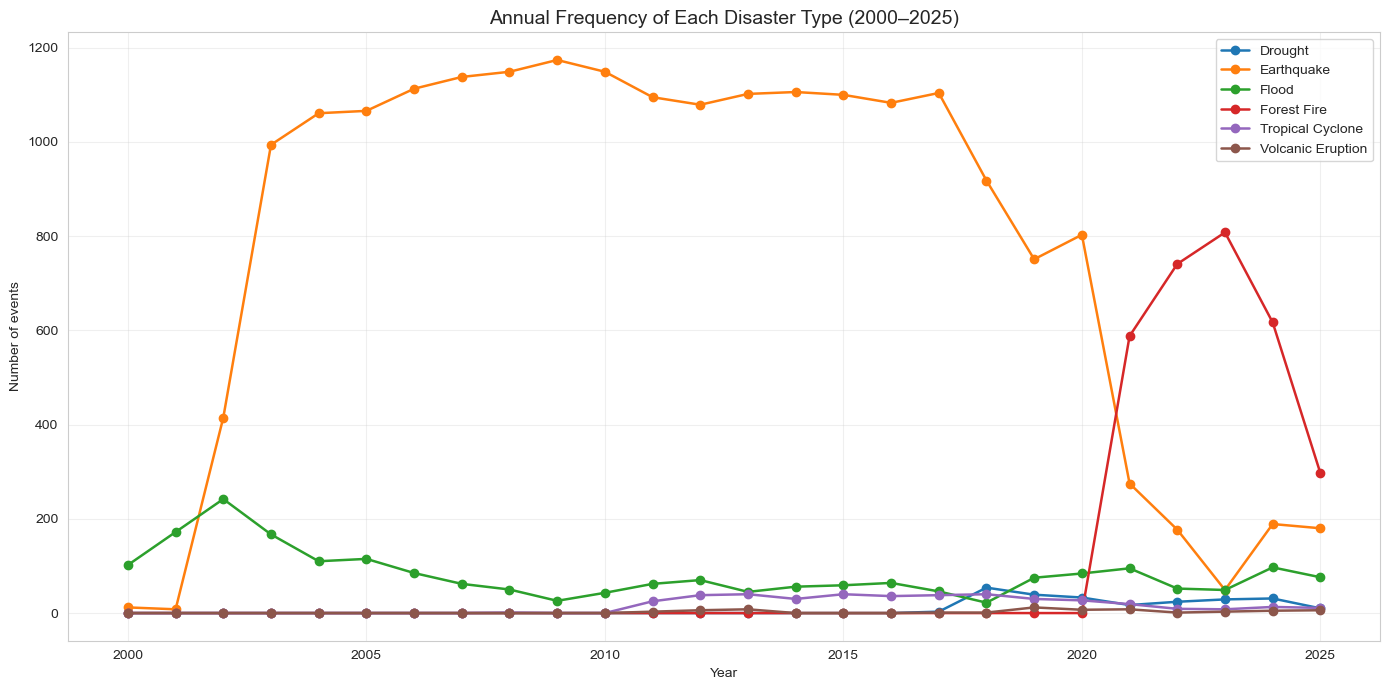

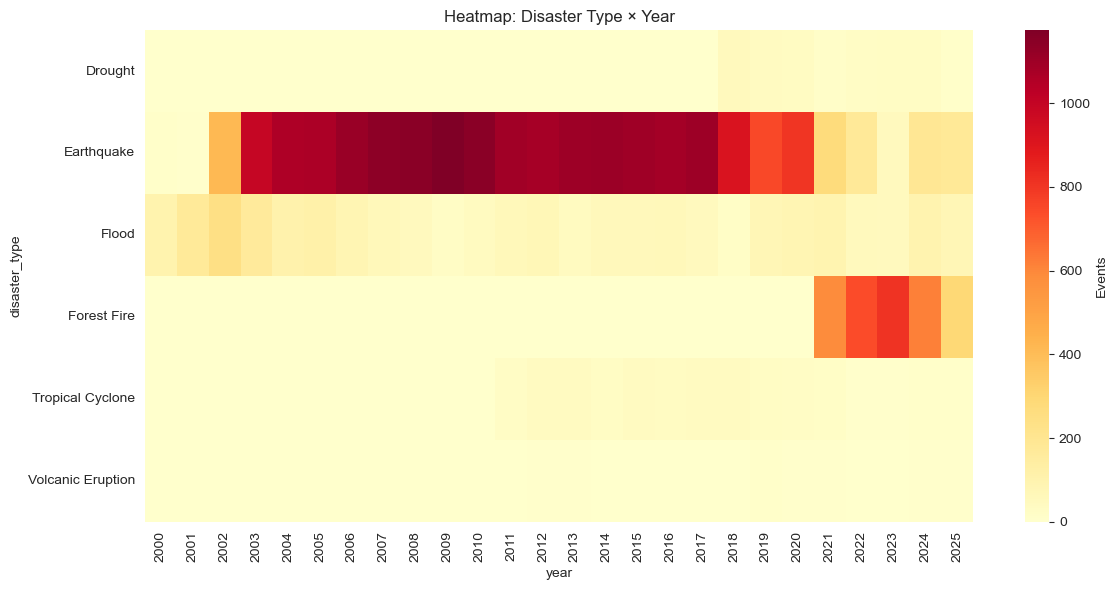

In [11]:
# Temporal patterns by disaster type (line plot)
yearly_type = master.groupby(['year', 'disaster_type']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
for col in yearly_type.columns:
    plt.plot(yearly_type.index, yearly_type[col], marker='o', label=col, linewidth=1.8)
plt.title('Annual Frequency of Each Disaster Type (2000–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of events')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap of year × type
plt.figure(figsize=(12, 6))
sns.heatmap(yearly_type.T, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Events'})
plt.title('Heatmap: Disaster Type × Year')
plt.tight_layout()
plt.show()

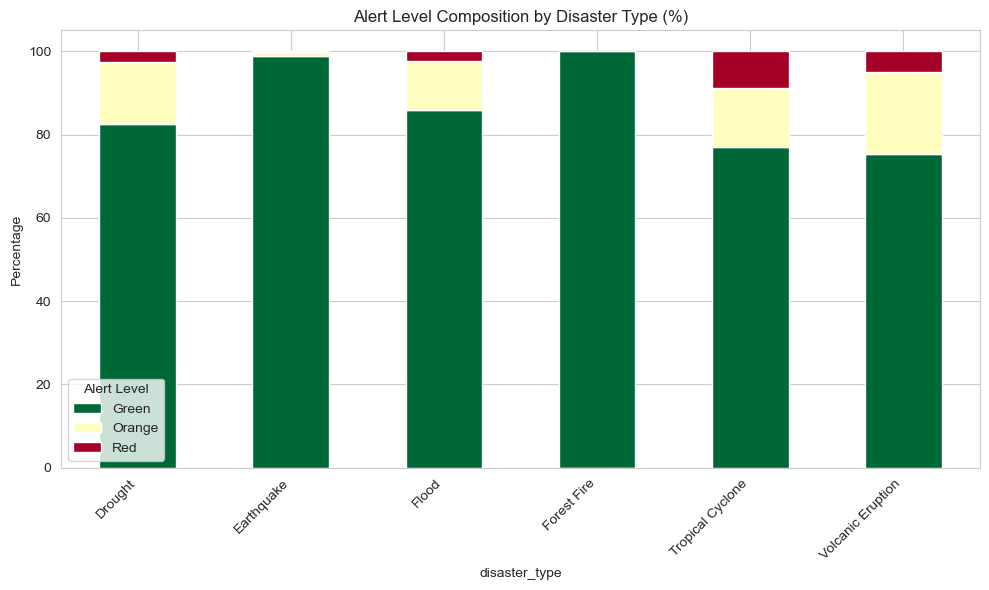

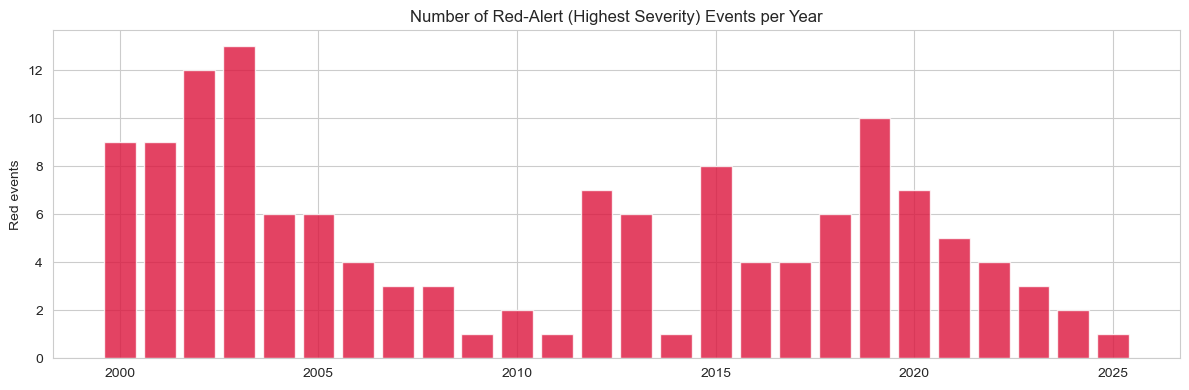

In [12]:
# Alert level (Green / Orange / Red) distribution by type and over time
alert_order = ['Green', 'Orange', 'Red']
master['alertlevel'] = pd.Categorical(master['alertlevel'], categories=alert_order, ordered=True)

# By type
ct = pd.crosstab(master['disaster_type'], master['alertlevel'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='RdYlGn_r')
plt.title('Alert Level Composition by Disaster Type (%)')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Alert Level')
plt.tight_layout()
plt.show()

# Red events over time
red = master[master['alertlevel'] == 'Red']
red_yearly = red.groupby('year').size()
plt.figure(figsize=(12, 4))
plt.bar(red_yearly.index, red_yearly.values, color='crimson', alpha=0.8)
plt.title('Number of Red-Alert (Highest Severity) Events per Year')
plt.ylabel('Red events')
plt.tight_layout()
plt.show()

In [13]:
# Build a country-level Disaster Burden / Humanitarian Priority proxy index
# Components:
# 1. Frequency (total events)
# 2. Severity (share of Orange+Red or mean alertscore)
# 3. Recurrence (number of distinct years with events)
# 4. Diversity (number of distinct disaster types)

country_stats = master.groupby('country_clean').agg(
    n_events=('disaster_type', 'size'),
    n_types=('disaster_type', 'nunique'),
    n_years=('year', 'nunique'),
    mean_alertscore=('alertscore', 'mean'),
    n_red=('alertlevel', lambda x: (x == 'Red').sum()),
    n_orange=('alertlevel', lambda x: (x == 'Orange').sum())
).reset_index()

# Simple composite index (normalised 0–1 then averaged)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = ['n_events', 'n_types', 'n_years', 'mean_alertscore', 'n_red']
country_stats[features] = country_stats[features].fillna(0)
scaled = scaler.fit_transform(country_stats[features])
country_stats['burden_index'] = scaled.mean(axis=1)

# Rank
country_stats = country_stats.sort_values('burden_index', ascending=False).reset_index(drop=True)
country_stats['rank'] = country_stats.index + 1

print("Top 20 Humanitarian Disaster Hotspots (Burden Index):")
print(country_stats[['rank', 'country_clean', 'n_events', 'n_types', 'n_years',
                     'n_red', 'mean_alertscore', 'burden_index']].head(20).round(3))

Top 20 Humanitarian Disaster Hotspots (Burden Index):
    rank       country_clean  n_events  n_types  n_years  n_red  mean_alertscore  burden_index
0      1           Indonesia      2522        6       26      7            1.030         0.673
1      2               India       559        5       26     20            1.143         0.619
2      3               China       688        5       26     18            1.142         0.609
3      4         Philippines       672        5       26     11            1.100         0.533
4      5       United States      1270        6       24      3            1.010         0.516
5      6               Japan      1447        4       25      4            1.012         0.468
6      7              Mexico       563        6       26      1            1.020         0.457
7      8              Canada       366        6       26      0            1.008         0.430
8      9  Offshore / Unknown      1965        2       24      4            1.013         0.

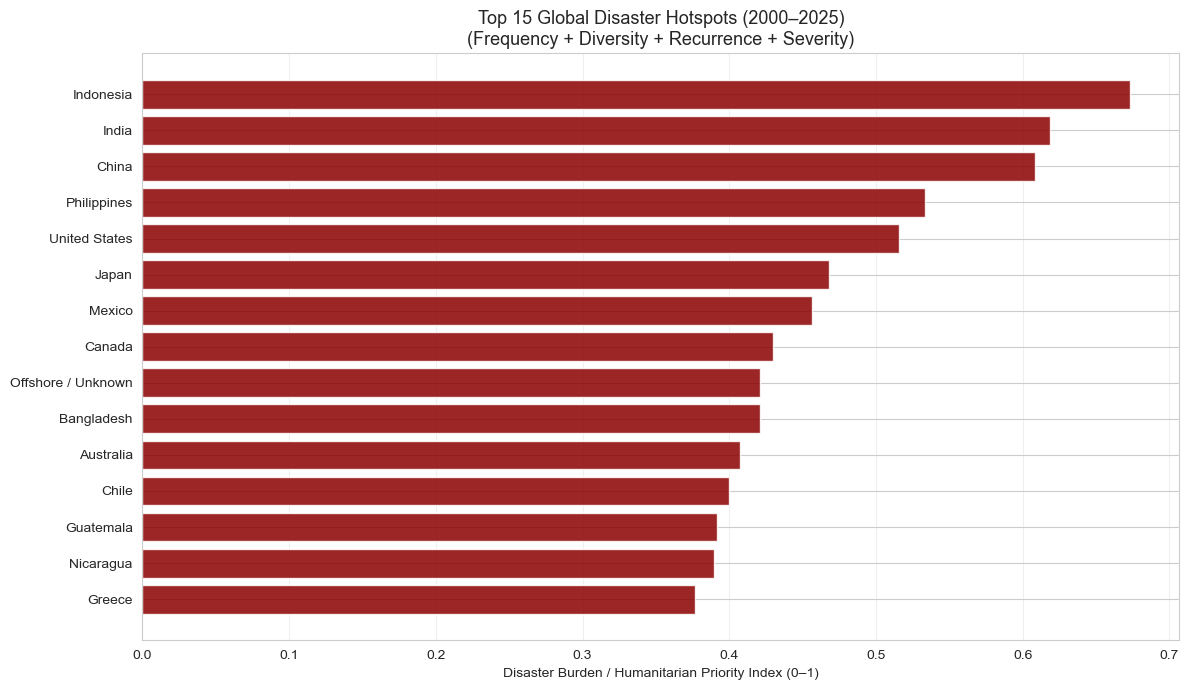


Countries exposed to 4 or more disaster types:
    country_clean  n_events  n_types  n_years  burden_index
0       Indonesia      2522        6       26         0.673
5           Japan      1447        4       25         0.468
4   United States      1270        6       24         0.516
11          Chile       846        4       25         0.400
14         Greece       780        4       24         0.376
2           China       688        5       26         0.609
3     Philippines       672        5       26         0.533
17         Russia       607        4       25         0.360
10      Australia       595        5       26         0.407
6          Mexico       563        6       26         0.457
1           India       559        5       26         0.619
24        Vanuatu       476        4       23         0.334
25        Türkiye       472        4       23         0.334
20           Peru       399        4       25         0.356
7          Canada       366        6       26       

In [14]:
# Visualize top 15 hotspots
top15 = country_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['country_clean'][::-1], top15['burden_index'][::-1], color='darkred', alpha=0.85)
ax.set_xlabel('Disaster Burden / Humanitarian Priority Index (0–1)')
ax.set_title('Top 15 Global Disaster Hotspots (2000–2025)\n(Frequency + Diversity + Recurrence + Severity)', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Multi-hazard countries (n_types >= 4)
multi = country_stats[country_stats['n_types'] >= 4].sort_values('n_events', ascending=False)
print("\nCountries exposed to 4 or more disaster types:")
print(multi[['country_clean', 'n_events', 'n_types', 'n_years', 'burden_index']].head(15).round(3))

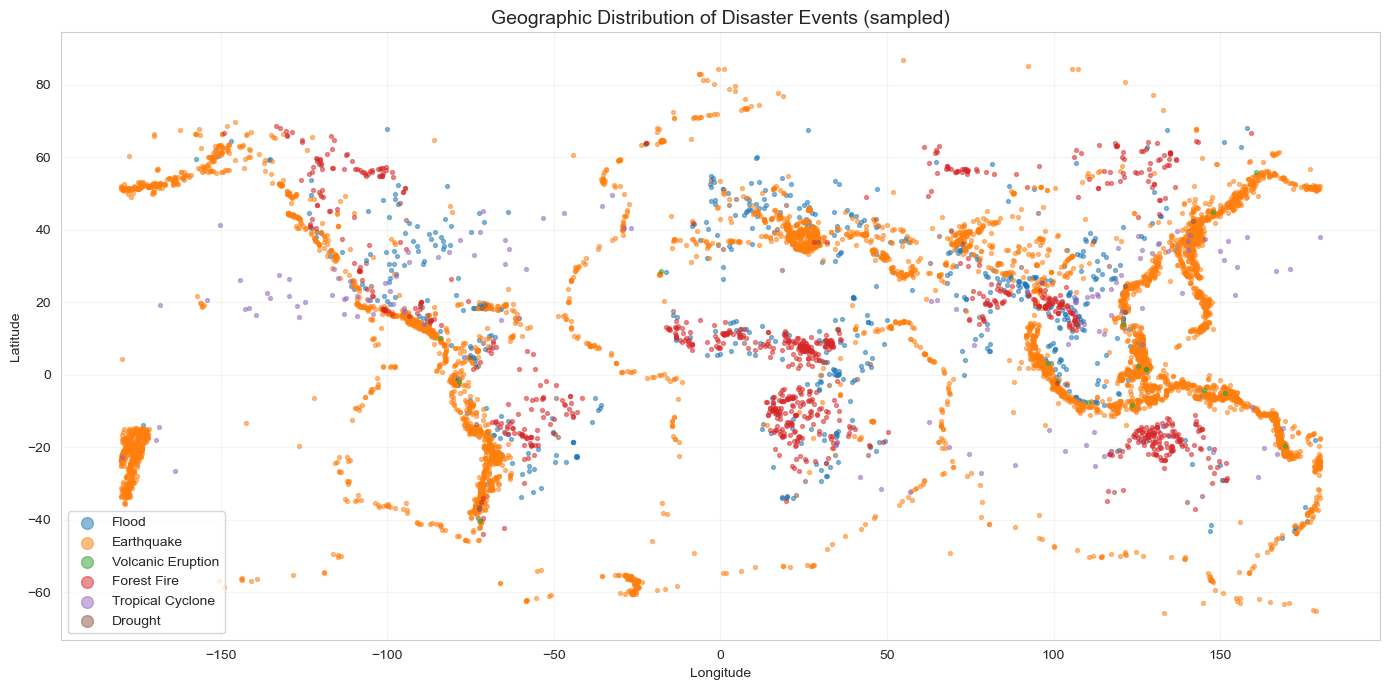

In [15]:
# Global spatial distribution (sample for speed)
# Earthquakes dominate; we sample or filter high-alert events
plot_df = master.dropna(subset=['longitude', 'latitude']).copy()
# Keep only reasonable coordinates
plot_df = plot_df[(plot_df['longitude'].between(-180, 180)) &
                  (plot_df['latitude'].between(-90, 90))]

# Sample if too large
if len(plot_df) > 8000:
    plot_df = plot_df.sample(8000, random_state=42)

plt.figure(figsize=(14, 7))
for dtype, color in zip(plot_df['disaster_type'].unique(),
                        sns.color_palette('tab10', n_colors=6)):
    sub = plot_df[plot_df['disaster_type'] == dtype]
    plt.scatter(sub['longitude'], sub['latitude'], s=8, alpha=0.5, label=dtype, c=[color])
plt.title('Geographic Distribution of Disaster Events (sampled)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(markerscale=3, loc='lower left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
# Create country × disaster-type count matrix
# (builds on the master dataframe created earlier)

type_counts = (master
               .groupby(['country_clean', 'disaster_type'])
               .size()
               .unstack(fill_value=0))

# Keep only countries that have at least a few events overall
type_counts = type_counts.loc[type_counts.sum(axis=1) >= 5]

print("Country × Disaster Type matrix shape:", type_counts.shape)
print("\nFirst 8 rows:")
print(type_counts.head(8))
print("\nColumn totals (global events per type):")
print(type_counts.sum().sort_values(ascending=False))

Country × Disaster Type matrix shape: (240, 6)

First 8 rows:
disaster_type                     Drought  Earthquake  Flood  Forest Fire  Tropical Cyclone  Volcanic Eruption
country_clean                                                                                                 
Afghanistan                             7         131     27            0                 0                  0
Afghanistan-Tajikistan Bord Reg.        0           5      0            0                 0                  0
Albania                                 3          41      7            1                 0                  0
Algeria                                 5          44     12            0                 0                  0
American Samoa                          0           5      1            0                 0                  0
Andreanof Islands                       0           5      0            0                 0                  0
Angola                                  6         

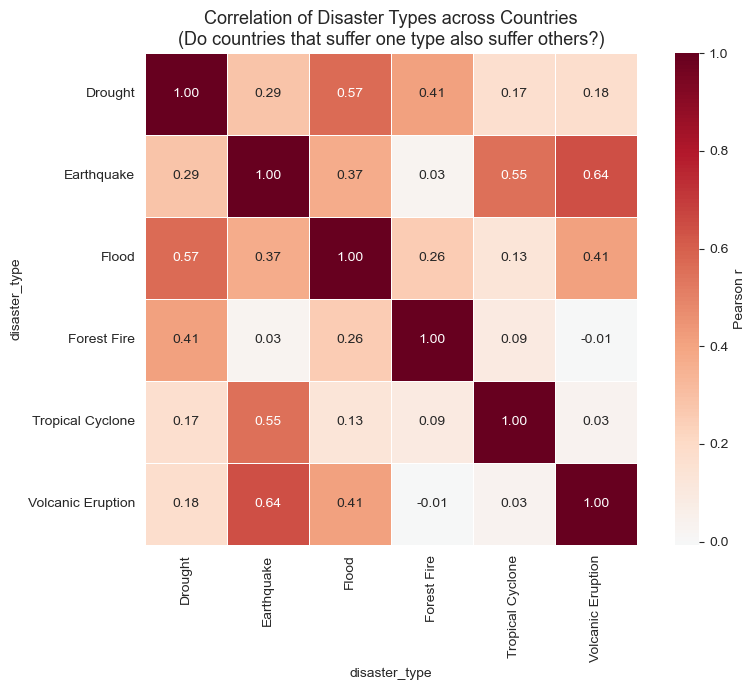


Correlation matrix:
disaster_type      Drought  Earthquake  Flood  Forest Fire  Tropical Cyclone  Volcanic Eruption
disaster_type                                                                                  
Drought              1.000       0.288  0.566        0.409             0.172              0.181
Earthquake           0.288       1.000  0.373        0.026             0.550              0.644
Flood                0.566       0.373  1.000        0.256             0.129              0.410
Forest Fire          0.409       0.026  0.256        1.000             0.094             -0.007
Tropical Cyclone     0.172       0.550  0.129        0.094             1.000              0.033
Volcanic Eruption    0.181       0.644  0.410       -0.007             0.033              1.000


In [17]:
# Pearson correlation between disaster types across countries
corr_matrix = type_counts.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of Disaster Types across Countries\n(Do countries that suffer one type also suffer others?)', 
          fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
print(corr_matrix.round(3))

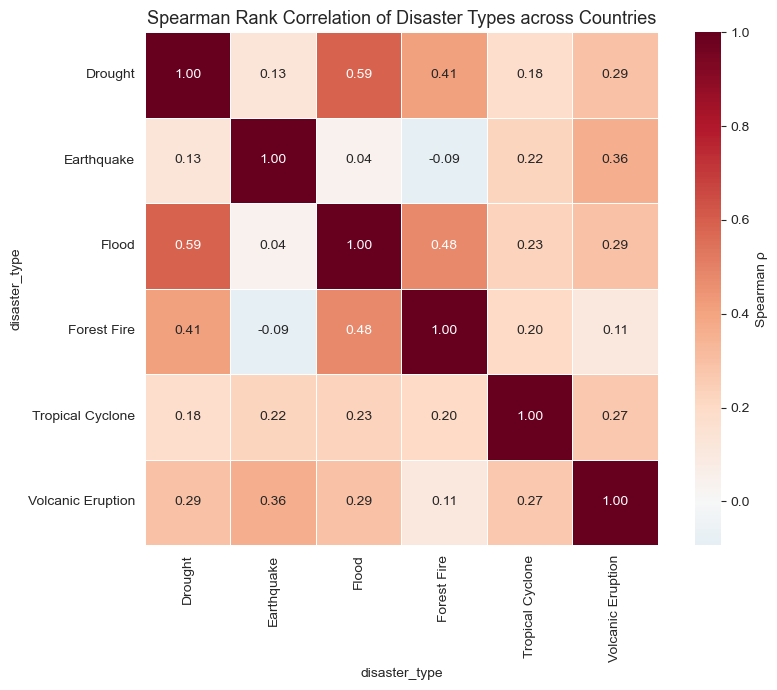


Spearman correlation matrix:
disaster_type      Drought  Earthquake  Flood  Forest Fire  Tropical Cyclone  Volcanic Eruption
disaster_type                                                                                  
Drought              1.000       0.129  0.586        0.410             0.180              0.294
Earthquake           0.129       1.000  0.044       -0.093             0.223              0.363
Flood                0.586       0.044  1.000        0.477             0.229              0.292
Forest Fire          0.410      -0.093  0.477        1.000             0.204              0.111
Tropical Cyclone     0.180       0.223  0.229        0.204             1.000              0.270
Volcanic Eruption    0.294       0.363  0.292        0.111             0.270              1.000


In [18]:
# Spearman correlation (rank-based, less sensitive to extreme countries)
corr_spearman = type_counts.corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Spearman ρ'})
plt.title('Spearman Rank Correlation of Disaster Types across Countries', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSpearman correlation matrix:")
print(corr_spearman.round(3))

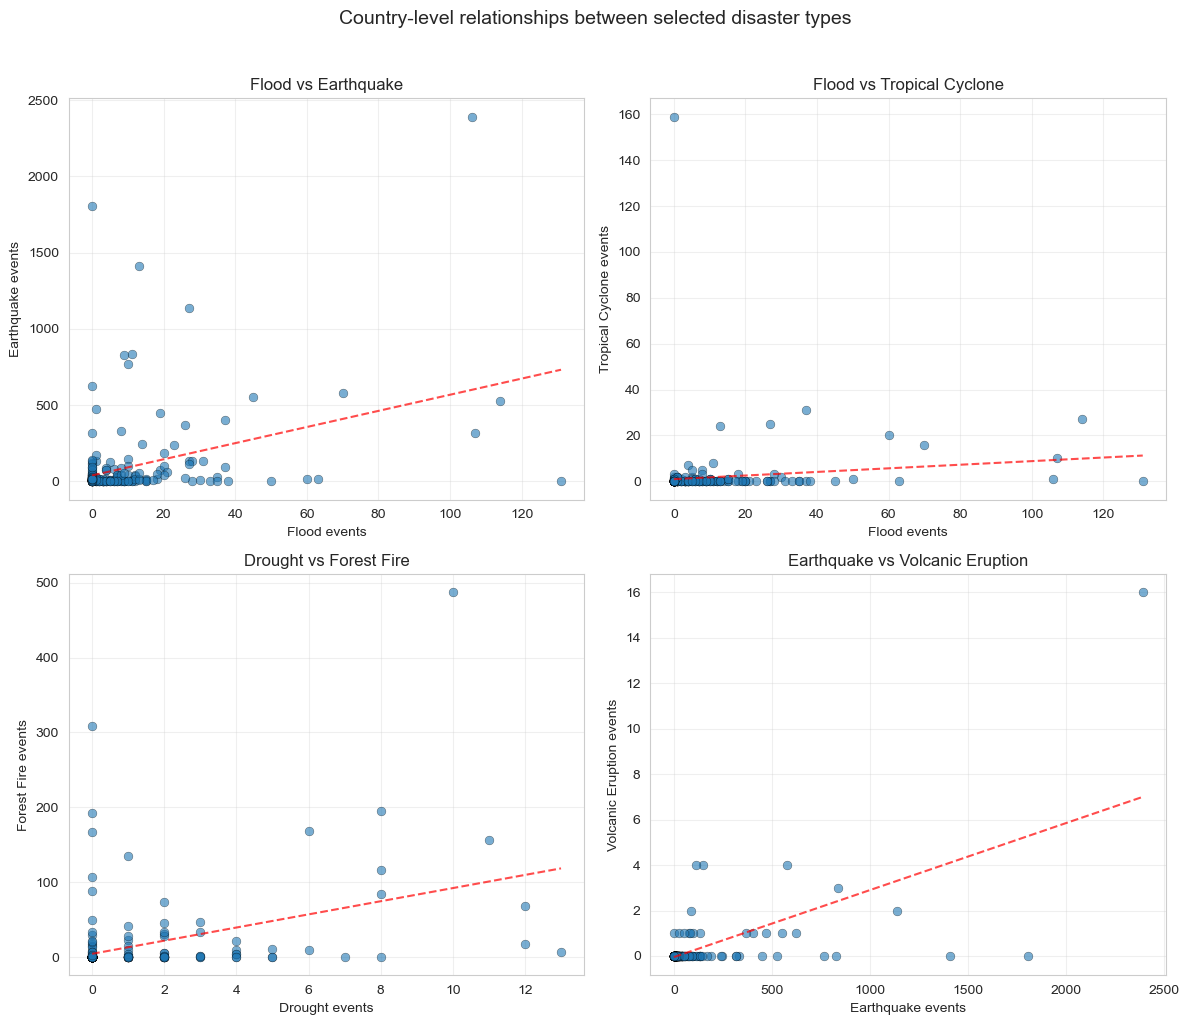

In [19]:
# Scatter plots to visualise relationships between selected pairs
pairs = [
    ('Flood', 'Earthquake'),
    ('Flood', 'Tropical Cyclone'),
    ('Drought', 'Forest Fire'),
    ('Earthquake', 'Volcanic Eruption')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(pairs):
    if x in type_counts.columns and y in type_counts.columns:
        axes[i].scatter(type_counts[x], type_counts[y], alpha=0.6, s=40, edgecolor='k', linewidth=0.3)
        axes[i].set_xlabel(f'{x} events')
        axes[i].set_ylabel(f'{y} events')
        axes[i].set_title(f'{x} vs {y}')
        # simple trend line
        z = np.polyfit(type_counts[x], type_counts[y], 1)
        p = np.poly1d(z)
        x_line = np.linspace(type_counts[x].min(), type_counts[x].max(), 50)
        axes[i].plot(x_line, p(x_line), 'r--', alpha=0.7)
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Country-level relationships between selected disaster types', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

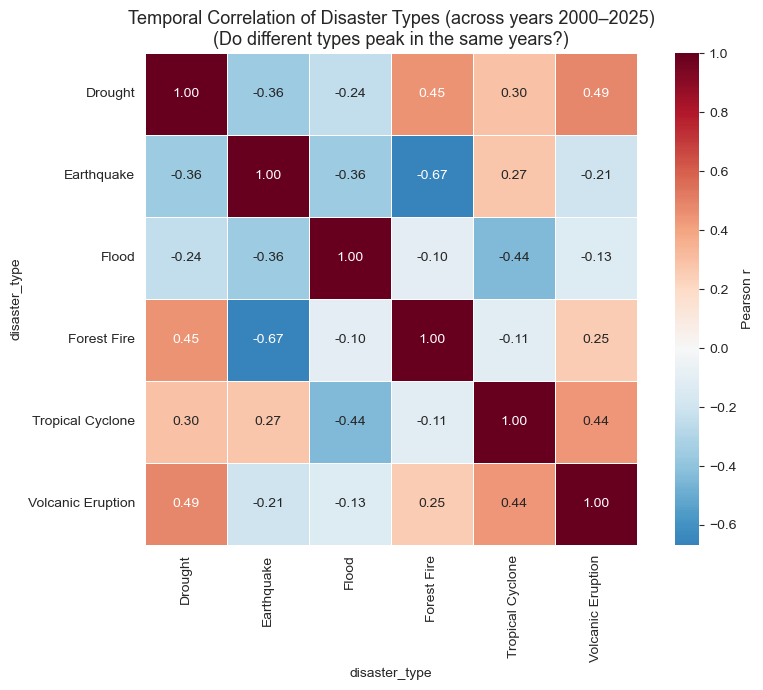


Year-level correlation matrix:
disaster_type      Drought  Earthquake  Flood  Forest Fire  Tropical Cyclone  Volcanic Eruption
disaster_type                                                                                  
Drought              1.000      -0.356 -0.238        0.449             0.296              0.488
Earthquake          -0.356       1.000 -0.363       -0.668             0.271             -0.208
Flood               -0.238      -0.363  1.000       -0.105            -0.441             -0.134
Forest Fire          0.449      -0.668 -0.105        1.000            -0.114              0.252
Tropical Cyclone     0.296       0.271 -0.441       -0.114             1.000              0.440
Volcanic Eruption    0.488      -0.208 -0.134        0.252             0.440              1.000


In [20]:
# Year-level correlation (do certain disaster types surge in the same years globally?)
yearly_type = master.groupby(['year', 'disaster_type']).size().unstack(fill_value=0)

# Correlation across years
yearly_corr = yearly_type.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(yearly_corr, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Temporal Correlation of Disaster Types (across years 2000–2025)\n(Do different types peak in the same years?)', 
          fontsize=13)
plt.tight_layout()
plt.show()

print("\nYear-level correlation matrix:")
print(yearly_corr.round(3))

## Correlation of Burden Index components

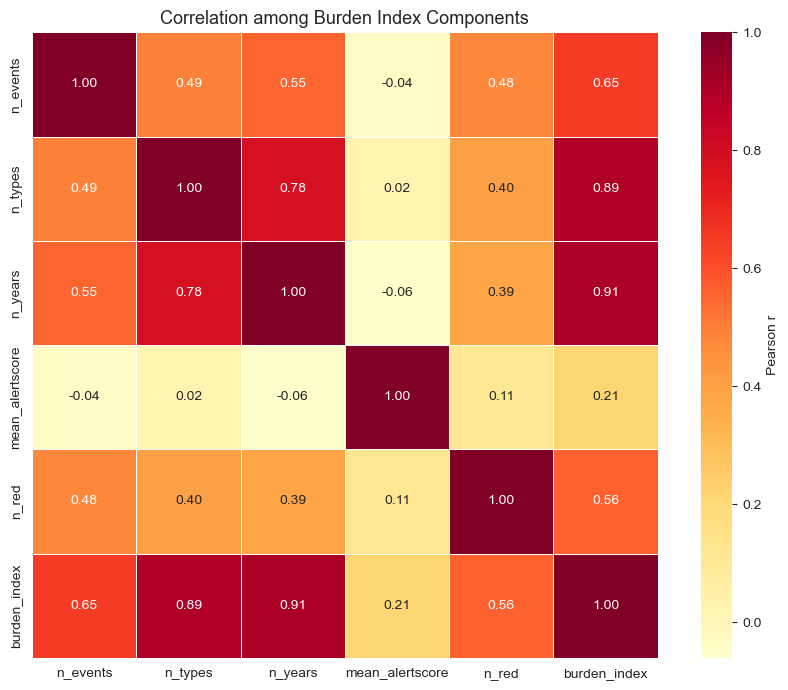


Component correlation matrix:
                 n_events  n_types  n_years  mean_alertscore  n_red  burden_index
n_events            1.000    0.491    0.553           -0.039  0.479         0.648
n_types             0.491    1.000    0.782            0.021  0.405         0.893
n_years             0.553    0.782    1.000           -0.060  0.385         0.907
mean_alertscore    -0.039    0.021   -0.060            1.000  0.113         0.214
n_red               0.479    0.405    0.385            0.113  1.000         0.562
burden_index        0.648    0.893    0.907            0.214  0.562         1.000


In [21]:
# How the components of the Humanitarian Priority Index relate to each other

components = ['n_events', 'n_types', 'n_years', 'mean_alertscore', 'n_red', 'burden_index']
comp_corr = country_stats[components].corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(comp_corr, 
            annot=True, 
            fmt='.2f', 
            cmap='YlOrRd', 
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation among Burden Index Components', fontsize=13)
plt.tight_layout()
plt.show()

print("\nComponent correlation matrix:")
print(comp_corr.round(3))

In [22]:
# Highlight multi-hazard countries that contribute most to correlations
# Countries with high counts in two or more high-correlation types

# Example: Flood + Tropical Cyclone (often linked in tropical regions)
if 'Flood' in type_counts.columns and 'Tropical Cyclone' in type_counts.columns:
    flood_tc = type_counts[['Flood', 'Tropical Cyclone']].copy()
    flood_tc['combined'] = flood_tc['Flood'] + flood_tc['Tropical Cyclone']
    flood_tc = flood_tc.sort_values('combined', ascending=False)
    
    print("Top 15 countries by combined Flood + Tropical Cyclone events:")
    print(flood_tc.head(15))

# Example: Drought + Forest Fire
if 'Drought' in type_counts.columns and 'Forest Fire' in type_counts.columns:
    drought_fire = type_counts[['Drought', 'Forest Fire']].copy()
    drought_fire['combined'] = drought_fire['Drought'] + drought_fire['Forest Fire']
    drought_fire = drought_fire.sort_values('combined', ascending=False)
    
    print("\nTop 15 countries by combined Drought + Forest Fire events:")
    print(drought_fire.head(15))

Top 15 countries by combined Flood + Tropical Cyclone events:
disaster_type       Flood  Tropical Cyclone  combined
country_clean                                        
Offshore / Unknown      0               159       159
China                 114                27       141
USA                   131                 0       131
India                 107                10       117
Indonesia             106                 1       107
Philippines            70                16        86
Australia              60                20        80
Mexico                 37                31        68
Brazil                 63                 0        63
United States          27                25        52
Vietnam                50                 1        51
Russia                 45                 0        45
Thailand               38                 0        38
Japan                  13                24        37
Pakistan               37                 0        37

Top 15 countries by

In [23]:
# Summary tables 
print("SUMMARY STATISTICS FOR RESEARCH")
print("\n1. Overall event counts by type (2000–2025):")
print(master['disaster_type'].value_counts().to_frame('events'))

print("\n2. Alert-level distribution:")
print(master['alertlevel'].value_counts(dropna=False).to_frame('count'))

print("\n3. Top 10 countries by total events:")
print(master['country_clean'].value_counts().head(10).to_frame('events'))

print("\n4. Countries with highest multi-hazard exposure (n_types >= 3):")
print(country_stats[country_stats['n_types'] >= 3]
      [['country_clean', 'n_events', 'n_types', 'n_years', 'burden_index']]
      .head(15).round(3).to_string(index=False))

print("\n5. Decade comparison (events per decade):")
master['decade'] = (master['year'] // 10) * 10
print(master.groupby('decade').size().to_frame('events'))

SUMMARY STATISTICS FOR RESEARCH

1. Overall event counts by type (2000–2025):
                   events
disaster_type            
Earthquake          20290
Forest Fire          3051
Flood                2126
Tropical Cyclone      405
Drought               240
Volcanic Eruption      61

2. Alert-level distribution:
            count
alertlevel       
Green       25488
Orange        548
Red           137

3. Top 10 countries by total events:
                    events
country_clean             
Indonesia             2522
Offshore / Unknown    1965
Japan                 1447
United States         1270
Papua New Guinea       851
Chile                  846
Greece                 780
China                  688
Philippines            672
Tonga                  624

4. Countries with highest multi-hazard exposure (n_types >= 3):
country_clean  n_events  n_types  n_years  burden_index
    Indonesia      2522        6       26         0.673
        India       559        5       26         0.619

In [25]:
# Quick textual summary of key correlation findings
print("KEY CORRELATION INSIGHTS")
print("\n1. Country-level (spatial) correlations:")
print("   - Look at the Pearson/Spearman heatmaps (Cells 18–19).")
print("   - Strong positive correlations indicate countries that tend to experience")
print("     multiple disaster types → higher multi-hazard preparedness needs.")

print("\n2. Temporal correlations:")
print("   - Positive values mean different disaster types tend to have high-event")
print("     years in the same periods (possible climate or reporting drivers).")
print("   - Near-zero or negative values suggest more independent temporal dynamics.")

print("\n3. Burden Index components:")
print("   - High correlation between n_events and n_years is expected (recurrence).")
print("   - Correlation of n_types with burden_index shows the importance of")
print("     multi-hazard diversity in the priority ranking.")

print("\n4. Practical implication for humanitarian response:")
print("   Countries appearing high on both Flood+Cyclone and Drought+Fire lists")
print("   (Cell 23) represent complex multi-hazard environments that require")
print("   diversified preparedness rather than single-hazard planning.")

KEY CORRELATION INSIGHTS

1. Country-level (spatial) correlations:
   - Look at the Pearson/Spearman heatmaps (Cells 18–19).
   - Strong positive correlations indicate countries that tend to experience
     multiple disaster types → higher multi-hazard preparedness needs.

2. Temporal correlations:
   - Positive values mean different disaster types tend to have high-event
     years in the same periods (possible climate or reporting drivers).
   - Near-zero or negative values suggest more independent temporal dynamics.

3. Burden Index components:
   - High correlation between n_events and n_years is expected (recurrence).
   - Correlation of n_types with burden_index shows the importance of
     multi-hazard diversity in the priority ranking.

4. Practical implication for humanitarian response:
   Countries appearing high on both Flood+Cyclone and Drought+Fire lists
   (Cell 23) represent complex multi-hazard environments that require
   diversified preparedness rather than single-haz